<a href="https://colab.research.google.com/github/mk143127/OrbitGuard-Space-Debris-Analysis/blob/main/OrbitGuard_Data_Monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello, welcome to OrbitGuard! Please hit the 'Run' button in order to begin.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.1/371.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 12.1 MB/s eta 0:00:00
🛰️ OrbitGuard: Space Debris Risk Map + Analysis
Loading cosmos-2251-debris...
Loading iridium-33-debris...
Loading fengyun-1c-debris...

Total debris objects mapped: 411


,Object Name,NORAD ID,Debris Group,Latitude,Longitude,Altitude_km,Risk
0,COSMOS 2251,22675,cosmos-2251-debris,57.643992,-139.422354,807.244231,Very High Risk
1,COSMOS 2251 DEB,33757,cosmos-2251-debris,-71.904582,141.434222,805.227741,Very High Risk
2,COSMOS 2251 DEB,33758,cosmos-2251-debris,31.223331,88.852013,722.589947,Very High Risk
3,COSMOS 2251 DEB,33760,cosmos-2251-debris,-11.617625,154.121606,780.210329,Very High Risk
4,COSMOS 2251 DEB,33761,cosmos-2251-debris,-49.654983,103.604647,773.099370,Very High Risk
5,COSMOS 2251 DEB,33762,cosmos-2251-debris,-35.354605,176.121321,790.569840,Very High Risk
6,COSMOS 2251 DEB,33764,cosmos-2251-debris,-72.962887,77.608877,799.830435,Very High Risk
7,COSMOS 2251 DEB,33765,cosmos-2251-debris,-8.386599,168.940990,507.182787,Very High Risk
8,COSMOS 2251 DEB,33766,cosmos-2251-debris,70.599664,142.265571,787.393725,Very High Risk
9,COSMOS 2251 DEB,33768,cosmos-2251-debris,35.632645,-42.885991,1290.663690,Very High Risk


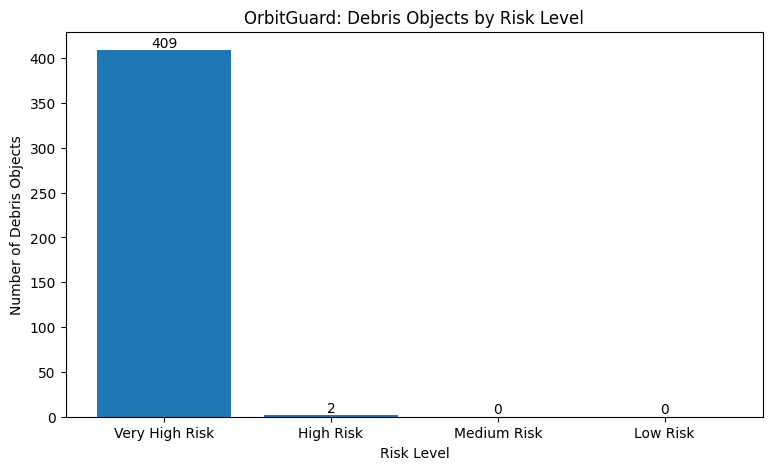

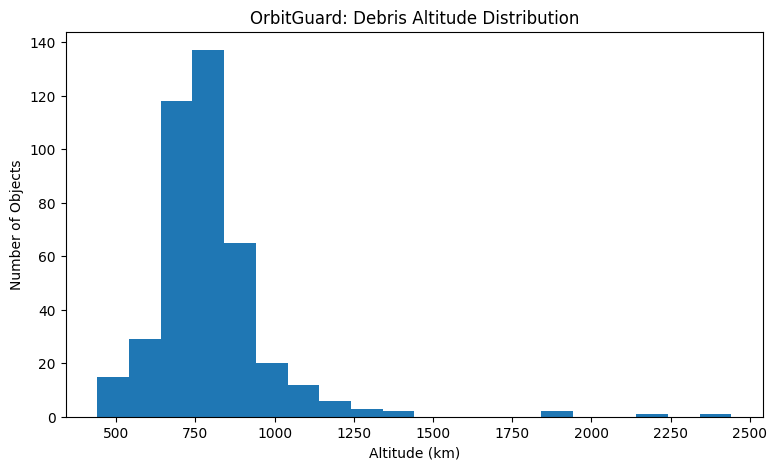


Risk Breakdown by Debris Group:
Risk                Very High Risk  High Risk  Medium Risk  Low Risk
Debris Group                                                        
cosmos-2251-debris             150          0            0         0
fengyun-1c-debris              148          2            0         0
iridium-33-debris              111          0            0         0

Altitude Summary:
Average altitude: 798.46 km
Lowest altitude: 440.65 km
Highest altitude: 2441.8 km

Top 10 Very High Risk Objects:


/tmp/ipykernel_768/2915654297.py:167: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Object Name,NORAD ID,Debris Group,Latitude,Longitude,Altitude_km
212,IRIDIUM 33 DEB,35622,iridium-33-debris,17.547164,-82.815708,440.653114
24,COSMOS 2251 DEB,33818,cosmos-2251-debris,-33.616165,166.960284,449.499269
26,COSMOS 2251 DEB,33821,cosmos-2251-debris,-38.164410,138.364192,458.392176
68,COSMOS 2251 DEB,33939,cosmos-2251-debris,32.528933,65.806538,466.571038
226,IRIDIUM 33 DEB,35929,iridium-33-debris,19.359842,-28.150207,495.606777
22,COSMOS 2251 DEB,33811,cosmos-2251-debris,9.305887,-65.260829,503.166804
7,COSMOS 2251 DEB,33765,cosmos-2251-debris,-8.386599,168.940990,507.182787
92,COSMOS 2251 DEB,34006,cosmos-2251-debris,39.435141,134.075185,511.853241
207,IRIDIUM 33 DEB,35484,iridium-33-debris,-43.406485,17.458700,523.203577
252,IRIDIUM 33 DEB,40996,iridium-33-debris,-13.344804,-157.698070,523.437757



📊 PROJECT SUMMARY
Total objects analyzed: 411
Very High Risk: 409
High Risk: 2
Medium Risk: 0
Low Risk: 0

Most dangerous debris group: cosmos-2251-debris

Key Insight:
Most debris is concentrated in Low Earth Orbit, making it the most crowded and high-risk region.

⚠️ DISCLAIMER

This project uses real orbital data from CelesTrak (TLE format).
The risk model is a simplified student-designed system based on altitude.

It does NOT calculate real collision probability.
Actual risk depends on velocity, trajectory, and proximity.

The map shows ground projection of orbiting objects, not their exact 3D position.

For educational purposes only.
Manha Kashif


Project complete 🚀


In [1]:
!pip install skyfield plotly pandas requests -q

import requests
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from skyfield.api import EarthSatellite, load, wgs84

# Clean display settings
pd.set_option('display.max_columns', None)

print("🛰️ OrbitGuard: Space Debris Risk Map + Analysis")

debris_groups = [
    "cosmos-2251-debris",
    "iridium-33-debris",
    "fengyun-1c-debris"
]

risk_order = ["Very High Risk", "High Risk", "Medium Risk", "Low Risk"]

all_objects = []

ts = load.timescale()
time_now = ts.now()

def fetch_tle_group(group_name):
    url = f"https://celestrak.org/NORAD/elements/gp.php?GROUP={group_name}&FORMAT=tle"
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
    lines = response.text.strip().splitlines()

    satellites = []
    for i in range(0, len(lines) - 2, 3):
        name = lines[i].strip()
        line1 = lines[i + 1].strip()
        line2 = lines[i + 2].strip()

        if line1.startswith("1 ") and line2.startswith("2 "):
            satellites.append((name, line1, line2))

    return satellites

def assign_risk(altitude_km):
    if altitude_km < 2000:
        return "Very High Risk"
    elif altitude_km < 10000:
        return "High Risk"
    elif altitude_km < 35786:
        return "Medium Risk"
    else:
        return "Low Risk"

for group in debris_groups:
    print(f"Loading {group}...")
    tle_data = fetch_tle_group(group)

    for name, line1, line2 in tle_data[:150]:
        try:
            satellite = EarthSatellite(line1, line2, name, ts)
            geocentric = satellite.at(time_now)
            subpoint = wgs84.subpoint(geocentric)

            all_objects.append({
                "Object Name": name,
                "NORAD ID": line1[2:7],
                "Debris Group": group,
                "Latitude": subpoint.latitude.degrees,
                "Longitude": subpoint.longitude.degrees,
                "Altitude_km": subpoint.elevation.km,
                "Risk": assign_risk(subpoint.elevation.km)
            })

        except:
            pass

data = pd.DataFrame(all_objects)

data["Risk"] = pd.Categorical(data["Risk"], categories=risk_order, ordered=True)

print("\nTotal debris objects mapped:", len(data))

# Clean table display
from IPython.display import display
display(data[[
    "Object Name",
    "NORAD ID",
    "Debris Group",
    "Latitude",
    "Longitude",
    "Altitude_km",
    "Risk"
]].head(10))

# =========================
# MAP 1: Risk Map
# =========================

fig = px.scatter_geo(
    data,
    lat="Latitude",
    lon="Longitude",
    color="Risk",
    hover_name="Object Name",
    hover_data=["NORAD ID", "Debris Group", "Altitude_km"],
    category_orders={"Risk": risk_order},
    title="OrbitGuard: Space Debris Risk Map"
)

fig.update_geos(showland=True, showocean=True, showcountries=True)
fig.show()

# =========================
# MAP 2: Altitude Map
# =========================

fig2 = px.scatter_geo(
    data,
    lat="Latitude",
    lon="Longitude",
    color="Altitude_km",
    hover_name="Object Name",
    hover_data=["NORAD ID", "Debris Group", "Risk"],
    title="OrbitGuard: Debris Altitude Map"
)

fig2.update_geos(showland=True, showocean=True, showcountries=True)
fig2.show()

# =========================
# GRAPH 1: Ordered Risk Graph
# =========================

risk_counts = data["Risk"].value_counts().reindex(risk_order, fill_value=0)

plt.figure(figsize=(9, 5))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("OrbitGuard: Debris Objects by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Debris Objects")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height),
             ha="center", va="bottom")

plt.show()

# =========================
# GRAPH 2: Altitude Distribution
# =========================

plt.figure(figsize=(9, 5))
plt.hist(data["Altitude_km"], bins=20)

plt.title("OrbitGuard: Debris Altitude Distribution")
plt.xlabel("Altitude (km)")
plt.ylabel("Number of Objects")

plt.show()

# =========================
# ANALYSIS
# =========================

print("\nRisk Breakdown by Debris Group:")
group_counts = data.groupby(["Debris Group", "Risk"]).size().unstack(fill_value=0)
print(group_counts)

print("\nAltitude Summary:")
print("Average altitude:", round(data["Altitude_km"].mean(), 2), "km")
print("Lowest altitude:", round(data["Altitude_km"].min(), 2), "km")
print("Highest altitude:", round(data["Altitude_km"].max(), 2), "km")

very_high_risk = data[data["Risk"] == "Very High Risk"]

print("\nTop 10 Very High Risk Objects:")
display(
    very_high_risk
    .sort_values(by="Altitude_km")
    [[
        "Object Name", "NORAD ID", "Debris Group",
        "Latitude", "Longitude", "Altitude_km"
    ]]
    .head(10)
)

# =========================
# SUMMARY + DISCLAIMER
# =========================

print("\n=========================")
print("📊 PROJECT SUMMARY")
print("=========================")

print(f"Total objects analyzed: {len(data)}")
print(f"Very High Risk: {risk_counts['Very High Risk']}")
print(f"High Risk: {risk_counts['High Risk']}")
print(f"Medium Risk: {risk_counts['Medium Risk']}")
print(f"Low Risk: {risk_counts['Low Risk']}")

most_dangerous_group = group_counts["Very High Risk"].idxmax()
print(f"\nMost dangerous debris group: {most_dangerous_group}")

print("\nKey Insight:")
print("Most debris is concentrated in Low Earth Orbit, making it the most crowded and high-risk region.")

print("\n=========================")
print("⚠️ DISCLAIMER")
print("=========================")

print("""
This project uses real orbital data from CelesTrak (TLE format).
The risk model is a simplified student-designed system based on altitude.

It does NOT calculate real collision probability.
Actual risk depends on velocity, trajectory, and proximity.

The map shows ground projection of orbiting objects, not their exact 3D position.

For educational purposes only.
Manha Kashif
""")

print("\nProject complete 🚀")

In [2]:
import numpy as np
import plotly.graph_objects as go

R_earth = 6371  # Approximate Earth's radius in kilometers

# Calculate Cartesian coordinates for debris objects
data_globe = data.copy()  # Create a copy to add new columns
data_globe['r'] = R_earth + data_globe['Altitude_km']
data_globe['lat_rad'] = np.radians(data_globe['Latitude'])
data_globe['lon_rad'] = np.radians(data_globe['Longitude'])

data_globe['x'] = data_globe['r'] * np.cos(data_globe['lat_rad']) * np.cos(data_globe['lon_rad'])
data_globe['y'] = data_globe['r'] * np.cos(data_globe['lat_rad']) * np.sin(data_globe['lon_rad'])
data_globe['z'] = data_globe['r'] * np.sin(data_globe['lat_rad'])

# Define colors for risk levels
risk_colors = {
    "Very High Risk": "red",
    "High Risk": "orange",
    "Medium Risk": "yellow",
    "Low Risk": "green"
}

# Create the debris scatter trace
debris_trace = go.Scatter3d(
    x=data_globe['x'],
    y=data_globe['y'],
    z=data_globe['z'],
    mode='markers',
    marker=dict(
        size=3,
        color=data_globe['Risk'].map(risk_colors),
        opacity=0.8
    ),
    text=data_globe['Object Name'],
    hoverinfo='text',
    name='Debris Objects',
    customdata=data_globe[['NORAD ID', 'Debris Group', 'Risk', 'Altitude_km', 'Latitude', 'Longitude']],
    hovertemplate="<b>%{text}</b><br>" +
                  "NORAD ID: %{customdata[0]}<br>" +
                  "Debris Group: %{customdata[1]}<br>" +
                  "Risk: %{customdata[2]}<br>" +
                  "Altitude (km): %{customdata[3]:.2f}<br>" +
                  "Latitude: %{customdata[4]:.2f}<br>" +
                  "Longitude: %{customdata[5]:.2f}"
)

# Create the globe trace (a sphere)
# Generate sphere coordinates
phi = np.linspace(0, 2 * np.pi, 100) # Longitude equivalent
theta = np.linspace(0, np.pi, 50)   # Latitude equivalent
x_globe = R_earth * np.outer(np.cos(phi), np.sin(theta))
y_globe = R_earth * np.outer(np.sin(phi), np.sin(theta))
z_globe = R_earth * np.outer(np.ones(100), np.cos(theta))

# Normalize z_globe to map to the colorscale range [0, 1]
z_normalized = (z_globe - z_globe.min()) / (z_globe.max() - z_globe.min())

globe_trace = go.Surface(
    x=x_globe,
    y=y_globe,
    z=z_globe,
    surfacecolor=z_normalized, # Use normalized z-coordinate for coloring
    colorscale=[
        [0.0, 'rgb(0,0,100)'],   # Deep ocean blue
        [0.25, 'rgb(0,0,255)'],   # Lighter ocean blue
        [0.5, 'rgb(0,100,0)'], # Greenish for land-like features
        [0.75, 'rgb(100,70,0)'],# Brownish for land-like features
        [1.0, 'rgb(0,0,100)']    # Wraps around for poles/other side
    ],
    showscale=False,
    opacity=0.6, # Make Earth transparent again
    name='Earth',
    hoverinfo='none'
)

# Combine traces into a figure
fig_globe = go.Figure(data=[globe_trace, debris_trace])

fig_globe.update_layout(
    title='OrbitGuard: 3D Space Debris Map Around Earth',
    scene_aspectmode='data',  # Ensures aspect ratios are correctly scaled
    scene_camera=dict(
        eye=dict(x=1.8, y=1.8, z=1.8)  # Adjust initial camera view
    ),
    margin=dict(l=0, r=0, b=0, t=40), # Adjust margins
    scene=dict(
        bgcolor='rgb(0,0,0)', # Black background for space
        xaxis=dict(showbackground=False, visible=False),
        yaxis=dict(showbackground=False, visible=False),
        zaxis=dict(showbackground=False, visible=False)
    ),
    paper_bgcolor='rgb(0,0,0)', # Black background for the entire plot
    font=dict(color='white') # Make text white for dark background
)

fig_globe.show()
